In [1]:
import torch
import torchvision
from lexplainet.implicit.rules import *

device = "cuda" if torch.cuda.is_available() else "cpu"

def model_loader(model_name, device):
    if model_name == "resnet18":
        model = torchvision.models.resnet18(pretrained=True)
    elif model_name == "resnet34":
        model = torchvision.models.resnet34(pretrained=True)
    elif model_name == "resnet50":
        model = torchvision.models.resnet50(pretrained=True)
    elif model_name == "vgg16":
        model = torchvision.models.vgg16(pretrained=True)
    elif model_name == "vgg16_bn":
        model = torchvision.models.vgg16_bn(pretrained=True)
    else:
        raise ValueError("Unsupported model name")
    
    model = model.to(device)
    model.device = device
    model.eval()
    return model

model = model_loader("resnet18", device)

/home/erfan/venvs/llm_pruning/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/erfan/venvs/llm_pruning/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

from imagenet import IMAGENET_CLASS_NAMES
from imagenet.utils import inference_transform
from lexplainet.heatmap import show_image, load_image, plot_heatmap

Image Tensor Shape: torch.Size([1, 3, 224, 224])


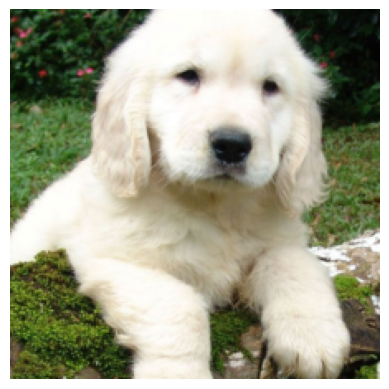

<Figure size 640x480 with 0 Axes>

In [3]:
image_tensor = load_image('./dog_1.png', transform=inference_transform, device=device)
show_image(image_tensor, transform=inference_transform)

In [4]:
from model_utils.inference import forward_pass
from model_utils.autograd import make_gradient_output, compute_relevance

In [5]:
from lexplainet.implicit.model_specific_patches import canonize_resnet
canonize_resnet(model)

Canonize linear and BatchNorm layers: conv1 and bn1
Canonize linear and BatchNorm layers: layer1.0.conv1 and layer1.0.bn1
Canonize linear and BatchNorm layers: layer1.0.conv2 and layer1.0.bn2
Canonize linear and BatchNorm layers: layer1.1.conv1 and layer1.1.bn1
Canonize linear and BatchNorm layers: layer1.1.conv2 and layer1.1.bn2
Canonize linear and BatchNorm layers: layer2.0.conv1 and layer2.0.bn1
Canonize linear and BatchNorm layers: layer2.0.conv2 and layer2.0.bn2
Canonize linear and BatchNorm layers: layer2.0.downsample.0 and layer2.0.downsample.1
Canonize linear and BatchNorm layers: layer2.1.conv1 and layer2.1.bn1
Canonize linear and BatchNorm layers: layer2.1.conv2 and layer2.1.bn2
Canonize linear and BatchNorm layers: layer3.0.conv1 and layer3.0.bn1
Canonize linear and BatchNorm layers: layer3.0.conv2 and layer3.0.bn2
Canonize linear and BatchNorm layers: layer3.0.downsample.0 and layer3.0.downsample.1
Canonize linear and BatchNorm layers: layer3.1.conv1 and layer3.1.bn1
Canoni

In [6]:
from lexplainet.implicit.composite_core import patch_composite, undo_patch_all
from lexplainet.implicit.rules import gamma_rule, identity_rule, epsilon_rule, lifted_gamma_rule

undo_patch_all(model)
composite = {
            torch.nn.Conv2d: (gamma_rule, {'gamma': 1000.}), 
            # torch.nn.Conv2d: (lifted_gamma_rule, {'gamma': 1000.}),
            torch.nn.ReLU: (identity_rule, {}),
            torch.nn.BatchNorm2d: (identity_rule, {}),
            torch.nn.Linear: (epsilon_rule, {})
}

patch_composite(model, composite)

/home/erfan/venvs/llm_pruning/lib/python3.10/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


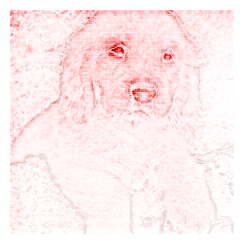

In [7]:
relevance, _ =compute_relevance(model,
              image_tensor,
              targeted=True,
              init_relevance=1,
              normalize=True)
plot_heatmap(relevance, image=image_tensor, save=False, edge_overlay=True)

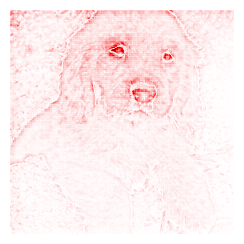

In [8]:
image_tensor.requires_grad = True

output = forward_pass(model, image_tensor, gradient_required=True)
predicted_class = output.argmax(dim=1).item()

gradient_output = make_gradient_output(output, predicted_class)
output.backward(gradient_output)

relevance = image_tensor.grad.detach().cpu() * image_tensor.detach().cpu()
lrp_normalized_relevance = (relevance / torch.max(torch.abs(relevance))).sum(dim=1)
plot_heatmap(lrp_normalized_relevance, save=True, save_path="resnet18_lrp_heatmap_dog_1.png")

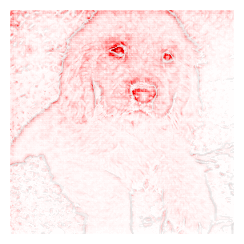

In [9]:
plot_heatmap(
    lrp_normalized_relevance,
    image=image_tensor,
    edge_overlay=True,)

Image Tensor Shape: torch.Size([1, 3, 224, 224])


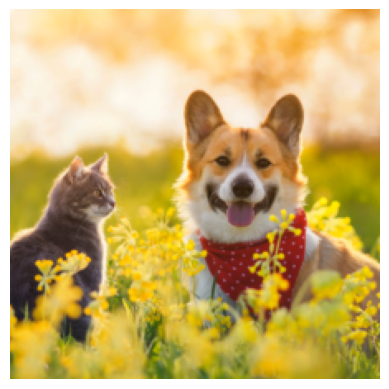

<Figure size 640x480 with 0 Axes>

In [13]:
image_tensor = load_image('./dog_2.png', transform=inference_transform, device=device)
show_image(image_tensor, transform=inference_transform)

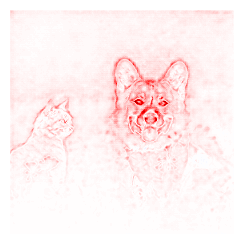

In [14]:
image_tensor.requires_grad = True

output = forward_pass(model, image_tensor, gradient_required=True)
predicted_class = output.argmax(dim=1).item()

gradient_output = make_gradient_output(output, predicted_class)
output.backward(gradient_output)

relevance = image_tensor.grad.detach().cpu() * image_tensor.detach().cpu()
lrp_normalized_relevance = (relevance / torch.max(torch.abs(relevance))).sum(dim=1)
plot_heatmap(lrp_normalized_relevance, save=True, save_path="resnet18_lrp_heatmap_dog_1.png")

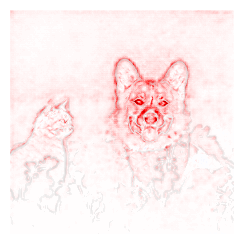

In [15]:
plot_heatmap(
    lrp_normalized_relevance,
    image=image_tensor,
    edge_overlay=True,
)

In [16]:
heatmap, clim = plot_heatmap(lrp_normalized_relevance, show=False)